# CSE422 Lab Project: Stroke Prediction Using Machine Learning

**Course:** CSE422 - Artificial Intelligence

---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Introduction

Stroke is one of the leading causes of death and disability worldwide. Early prediction of stroke risk can help in timely medical intervention and potentially save lives.

This project aims to build a Machine Learning pipeline to predict whether a patient is likely to have a stroke based on various health and demographic features. We use the **Healthcare Dataset - Stroke Data**, which contains patient information such as age, gender, BMI, glucose level, and other clinical indicators.

**Problem Type:** Binary Classification (Stroke = 1, No Stroke = 0)

**Pipeline:** Load Dataset → EDA + Preprocessing → Train/Val/Test Split → Scaling → Train Models → Evaluate

## 2. Dataset Description

### 2.1 Loading the Dataset

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, classification_report
)
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Upload the dataset (Google Colab)
from google.colab import files
uploaded = files.upload()

Saving healthcare-dataset-stroke-data.csv to healthcare-dataset-stroke-data (1).csv


In [ ]:
# Load the dataset
df = pd.read_csv('healthcare-dataset-stroke-data.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### 2.2 Basic Dataset Information

In [ ]:
print(f"Number of data points (rows): {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"\nColumn names: {list(df.columns)}")

Number of data points (rows): 5110
Number of columns: 12

Column names: ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
df.describe(include='all')

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


### 2.3 Feature Analysis

| Property | Details |
|---|---|
| **Total Features** | 12 columns (1 identifier, 10 input features, 1 target) |
| **Data Points** | 5110 |
| **Problem Type** | Classification — the target `stroke` is binary (0 or 1) |
| **Quantitative Features** | `age`, `avg_glucose_level`, `bmi` |
| **Categorical Features** | `gender`, `ever_married`, `work_type`, `Residence_type`, `smoking_status` |
| **Binary Numeric Features** | `hypertension`, `heart_disease` |
| **Target Variable** | `stroke` (0 = No Stroke, 1 = Stroke) |
| **Identifier** | `id` (will be dropped — not a predictive feature) |

**Do we need to encode categorical variables?**
Yes. Machine learning models require numerical inputs. Categorical features like `gender`, `work_type`, `Residence_type`, `smoking_status`, and `ever_married` need to be encoded into numerical form.

### 2.4 Correlation Analysis

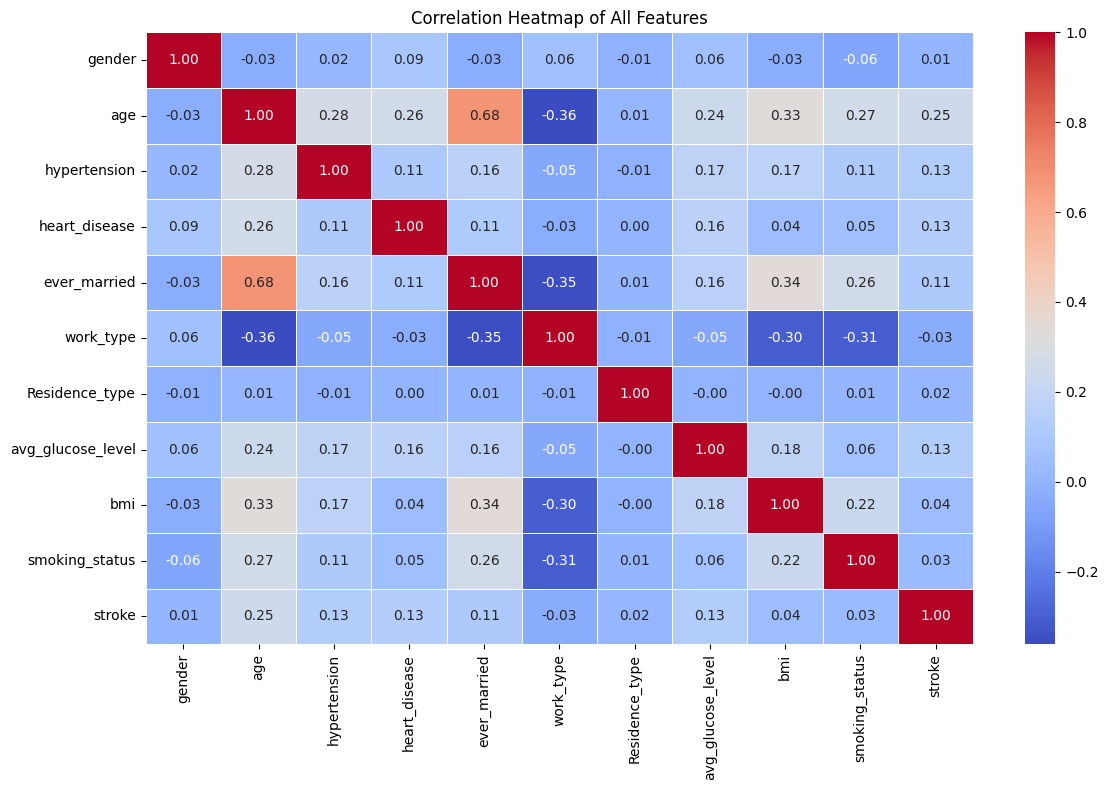

In [ ]:
# Encode categorical variables temporarily for correlation
df_corr = df.drop('id', axis=1).copy()
le = LabelEncoder()
for col in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

plt.figure(figsize=(12, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of All Features')
plt.tight_layout()
plt.show()

**Observations from the Correlation Heatmap:**
- `age` has the highest positive correlation with `stroke`, indicating that older patients are more likely to have strokes.
- `hypertension` and `heart_disease` also show positive correlation with `stroke`.
- `avg_glucose_level` has a moderate positive correlation with `stroke`.
- Features like `Residence_type` show very weak correlation with `stroke`.
- Overall, correlations with `stroke` are relatively weak, making this a challenging classification task.

### 2.5 Imbalanced Dataset Analysis

Distribution of target variable 'stroke':
stroke
0    4861
1     249
Name: count, dtype: int64

Percentage:
stroke
0    95.13
1     4.87
Name: proportion, dtype: float64


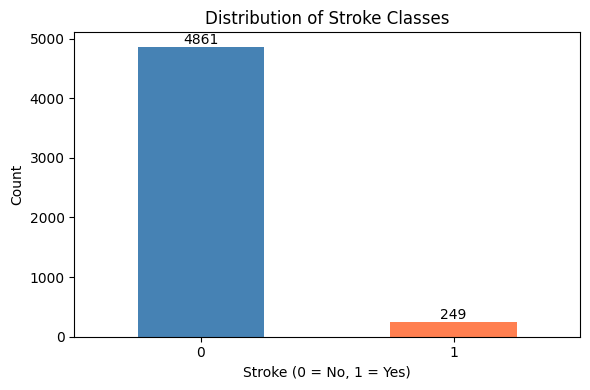

In [ ]:
print("Distribution of target variable 'stroke':")
print(df['stroke'].value_counts())
print(f"\nPercentage:")
print(round(df['stroke'].value_counts(normalize=True) * 100, 2))

plt.figure(figsize=(6, 4))
ax = df['stroke'].value_counts().plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Distribution of Stroke Classes')
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

**Observation:** The dataset is **heavily imbalanced**. Approximately 95% of patients did not have a stroke (class 0) and only about 5% had a stroke (class 1). This imbalance can cause models to be biased toward predicting the majority class. We will address this using **random oversampling** on the training set.

### 2.6 Exploratory Data Analysis (EDA)

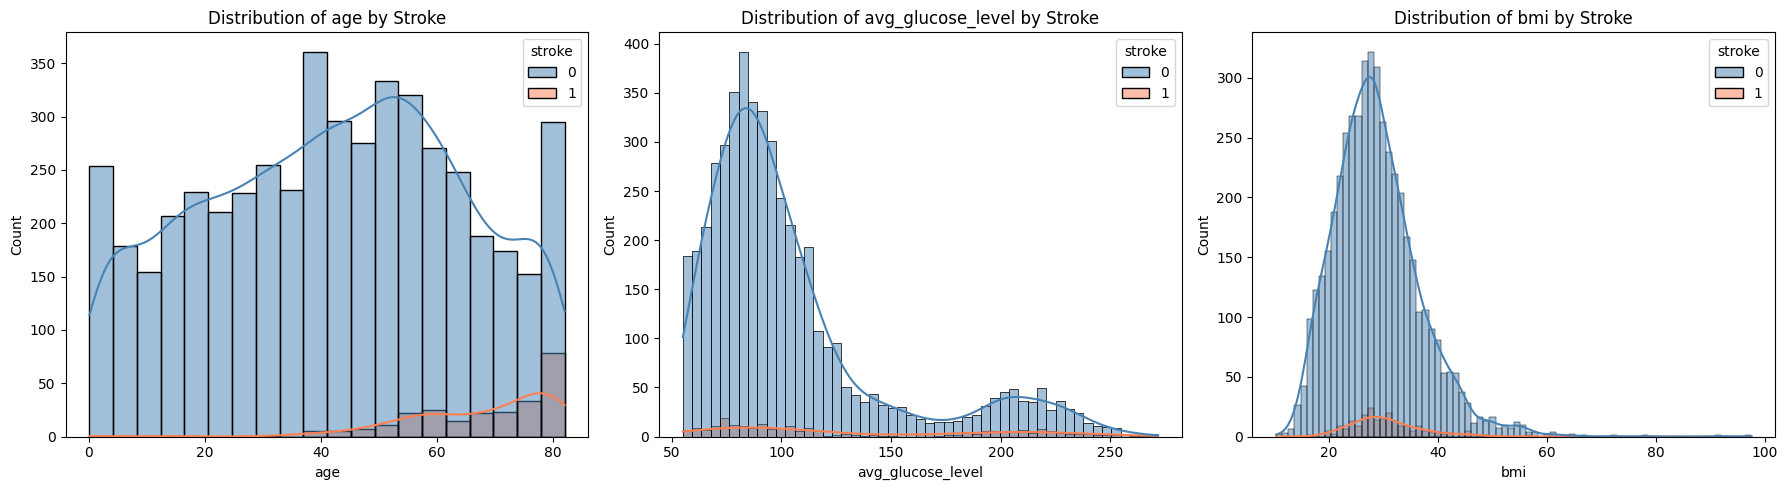

In [ ]:
# Distribution of numerical features by stroke
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(['age', 'avg_glucose_level', 'bmi']):
    sns.histplot(data=df, x=col, hue='stroke', kde=True, ax=axes[i], palette=['steelblue', 'coral'])
    axes[i].set_title(f'Distribution of {col} by Stroke')
plt.tight_layout()
plt.show()

In [ ]:
# Count plots for categorical features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
cat_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'smoking_status']
for i, col in enumerate(cat_cols):
    row, col_idx = i // 3, i % 3
    sns.countplot(data=df, x=col, hue='stroke', ax=axes[row][col_idx], palette=['steelblue', 'coral'])
    axes[row][col_idx].set_title(f'{col} by Stroke')
    axes[row][col_idx].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Box plots for numerical features by stroke
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(['age', 'avg_glucose_level', 'bmi']):
    sns.boxplot(data=df, x='stroke', y=col, ax=axes[i], palette=['steelblue', 'coral'])
    axes[i].set_title(f'{col} by Stroke')
plt.tight_layout()
plt.show()

## 3. Dataset Preprocessing

### 3.1 Problem: Irrelevant Feature (`id`)
The `id` column is a unique identifier and has no predictive value. We drop it.

In [ ]:
df = df.drop('id', axis=1)
print(f"After dropping 'id', shape: {df.shape}")

After dropping 'id', shape: (5110, 11)


### 3.2 Problem: Missing Values
The `bmi` column contains missing values. We impute them with the **median** value because median is robust to outliers. We choose imputation over deletion to preserve data points in an already small dataset.

In [ ]:
print(f"Missing values in 'bmi': {df['bmi'].isnull().sum()}")
bmi_median = df['bmi'].median()
df['bmi'].fillna(bmi_median, inplace=True)
print(f"Imputed missing 'bmi' values with median: {bmi_median}")
print(f"Missing values after imputation: {df['bmi'].isnull().sum()}")

Missing values in 'bmi': 201
Imputed missing 'bmi' values with median: 28.1
Missing values after imputation: 0


### 3.3 Problem: Rare Category
The `gender` column has an 'Other' category with only 1 sample. This is too rare to be useful and could cause issues during splitting. We remove it.

In [ ]:
print(f"Gender value counts:\n{df['gender'].value_counts()}")
df = df[df['gender'] != 'Other']
print(f"\nAfter removing 'Other', shape: {df.shape}")

Gender value counts:
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

After removing 'Other', shape: (5109, 11)


### 3.4 Problem: Categorical Variables Need Encoding
We use **One-Hot Encoding** (`pd.get_dummies`) to convert categorical features into numerical form. We set `drop_first=True` to avoid multicollinearity.

In [ ]:
df = pd.get_dummies(df, columns=['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'], drop_first=True)
print(f"After encoding, shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

After encoding, shape: (5109, 16)
Columns: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke', 'gender_Male', 'ever_married_Yes', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,True,True,False,True,False,False,True,True,False,False
1,61.0,0,0,202.21,28.1,1,False,True,False,False,True,False,False,False,True,False
2,80.0,0,1,105.92,32.5,1,True,True,False,True,False,False,False,False,True,False
3,49.0,0,0,171.23,34.4,1,False,True,False,True,False,False,True,False,False,True
4,79.0,1,0,174.12,24.0,1,False,True,False,False,True,False,False,False,True,False


## 4. Dataset Splitting

We use **Stratified Splitting** to maintain the class distribution across train, validation, and test sets. This is important because of the severe class imbalance.
- **70%** Training
- **15%** Validation
- **15%** Test

In [ ]:
# Separate features and target
X = df.drop('stroke', axis=1)
y = df['stroke']

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
# Second split: 50/50 on temp -> 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Training set:   {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set:       {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:\n{y_train.value_counts()}")

Training set:   3576 samples
Validation set: 766 samples
Test set:       767 samples

Training set class distribution:
stroke
0    3402
1     174
Name: count, dtype: int64


### 4.1 Handling Class Imbalance — Random Oversampling

The training set is heavily imbalanced. To fix this, we **randomly oversample** the minority class (stroke=1) by duplicating its samples until it matches the majority class count. This is done **only on the training set** to avoid data leakage.

In [ ]:
# Combine for resampling
train_data = X_train.copy()
train_data['stroke'] = y_train.values

majority = train_data[train_data['stroke'] == 0]
minority = train_data[train_data['stroke'] == 1]

print(f"Before oversampling:")
print(f"  Majority class (0): {len(majority)}")
print(f"  Minority class (1): {len(minority)}")

# Upsample minority class
minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=42)
train_balanced = pd.concat([majority, minority_upsampled])

X_train_balanced = train_balanced.drop('stroke', axis=1)
y_train_balanced = train_balanced['stroke']

print(f"\nAfter oversampling:")
print(f"  Class 0: {(y_train_balanced == 0).sum()}")
print(f"  Class 1: {(y_train_balanced == 1).sum()}")

Before oversampling:
  Majority class (0): 3402
  Minority class (1): 174

After oversampling:
  Class 0: 3402
  Class 1: 3402


## 5. Feature Scaling / Normalization

We apply **StandardScaler** (z-score normalization) to all features. The scaler is **fit only on the training set** and then used to transform validation and test sets to prevent data leakage.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print("Feature scaling applied successfully.")
print(f"Scaled training set shape: {X_train_scaled.shape}")

Feature scaling applied successfully.
Scaled training set shape: (6804, 15)


## 6. Model Training & Testing (Supervised)

We train **3 supervised models** as required:
1. **Neural Network** (mandatory) — `MLPClassifier` from scikit-learn
2. **Logistic Regression** — a simple linear model, good baseline for binary classification
3. **Decision Tree** — easy to interpret and understand

### 6.1 Model 1: Neural Network (MLPClassifier)

In [ ]:
nn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)
nn_model.fit(X_train_scaled, y_train_balanced)

y_pred_nn = nn_model.predict(X_test_scaled)
y_prob_nn = nn_model.predict_proba(X_test_scaled)[:, 1]

print("Neural Network — Test Set Results:")
print(classification_report(y_test, y_pred_nn))

Neural Network — Test Set Results:
              precision    recall  f1-score   support

           0       0.96      0.93      0.95       729
           1       0.14      0.21      0.17        38

    accuracy                           0.90       767
   macro avg       0.55      0.57      0.56       767
weighted avg       0.92      0.90      0.91       767



### 6.2 Model 2: Logistic Regression

In [ ]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train_balanced)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression — Test Set Results:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression — Test Set Results:
              precision    recall  f1-score   support

           0       0.99      0.73      0.84       729
           1       0.14      0.82      0.23        38

    accuracy                           0.73       767
   macro avg       0.56      0.77      0.54       767
weighted avg       0.94      0.73      0.81       767



### 6.3 Model 3: Decision Tree

In [ ]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_scaled, y_train_balanced)

y_pred_dt = dt_model.predict(X_test_scaled)
y_prob_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

print("Decision Tree — Test Set Results:")
print(classification_report(y_test, y_pred_dt))

Decision Tree — Test Set Results:
              precision    recall  f1-score   support

           0       0.98      0.70      0.82       729
           1       0.12      0.76      0.20        38

    accuracy                           0.70       767
   macro avg       0.55      0.73      0.51       767
weighted avg       0.94      0.70      0.78       767



## 7. Unsupervised Learning — KMeans Clustering

We treat the problem as an unsupervised learning task by applying **KMeans (k=2)** on the test features (without labels) and comparing the discovered clusters to the actual stroke labels.

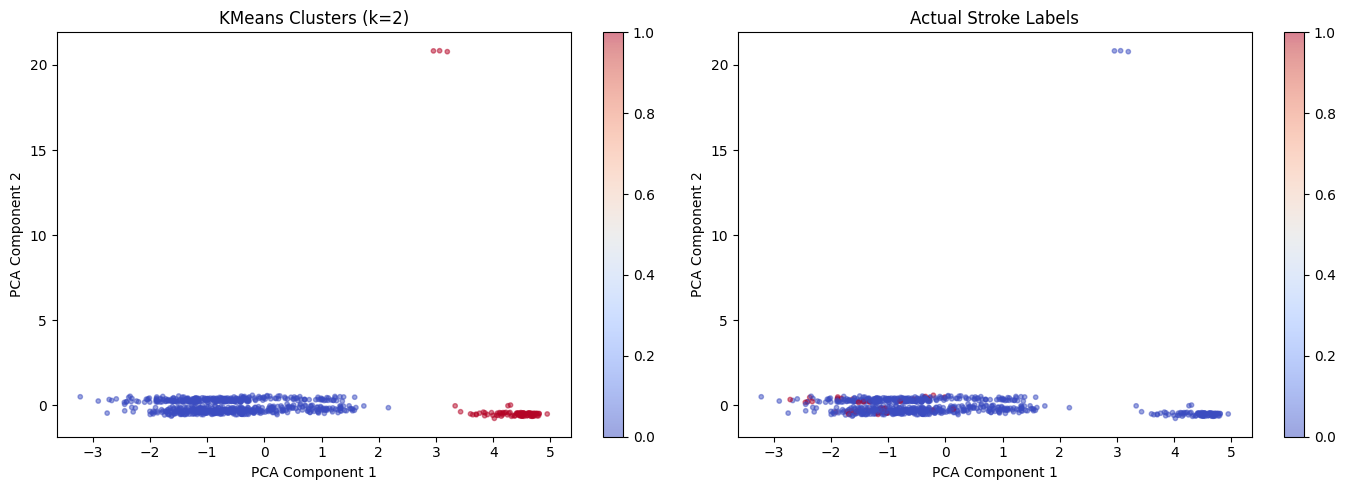

In [ ]:
# KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_test_scaled)

# PCA for 2D visualization
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter1 = axes[0].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=cluster_labels, cmap='coolwarm', alpha=0.5, s=10)
axes[0].set_title('KMeans Clusters (k=2)')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
plt.colorbar(scatter1, ax=axes[0])

scatter2 = axes[1].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test.values, cmap='coolwarm', alpha=0.5, s=10)
axes[1].set_title('Actual Stroke Labels')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()

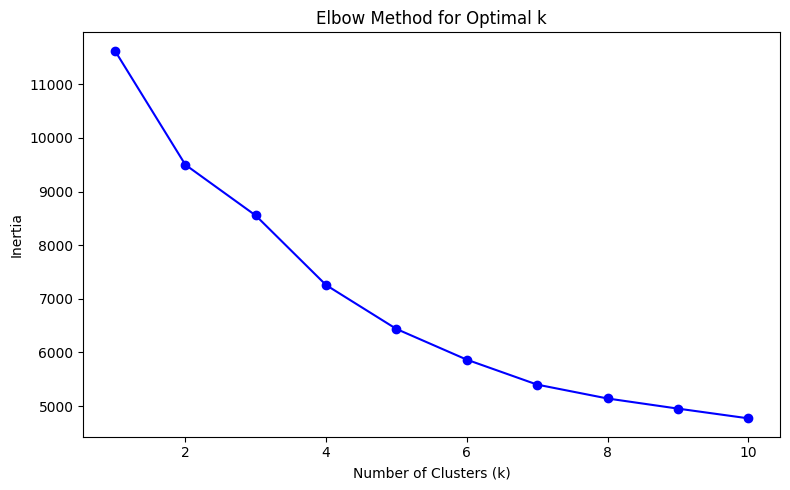

In [ ]:
# Elbow method to validate k=2
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_test_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.tight_layout()
plt.show()

## 8. Model Evaluation & Comparison

We evaluate all 3 supervised models using: **Accuracy, Precision, Recall, F1-Score, Confusion Matrix, AUC Score, and ROC Curve**.

In [ ]:
# Compute metrics for all models
models = {
    'Neural Network': (y_pred_nn, y_prob_nn),
    'Logistic Regression': (y_pred_lr, y_prob_lr),
    'Decision Tree': (y_pred_dt, y_prob_dt)
}

results = []
for name, (y_pred, y_prob) in models.items():
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1 Score': round(f1_score(y_test, y_pred), 4),
        'AUC': round(roc_auc_score(y_test, y_prob), 4)
    })

results_df = pd.DataFrame(results)
print("Model Comparison Summary:")
print(results_df.to_string(index=False))

Model Comparison Summary:
              Model  Accuracy  Precision  Recall  F1 Score    AUC
     Neural Network    0.8983     0.1429  0.2105    0.1702 0.7385
Logistic Regression    0.7327     0.1354  0.8158    0.2322 0.8366
      Decision Tree    0.7001     0.1160  0.7632    0.2014 0.7716


### 8.1 Accuracy Comparison — Bar Chart

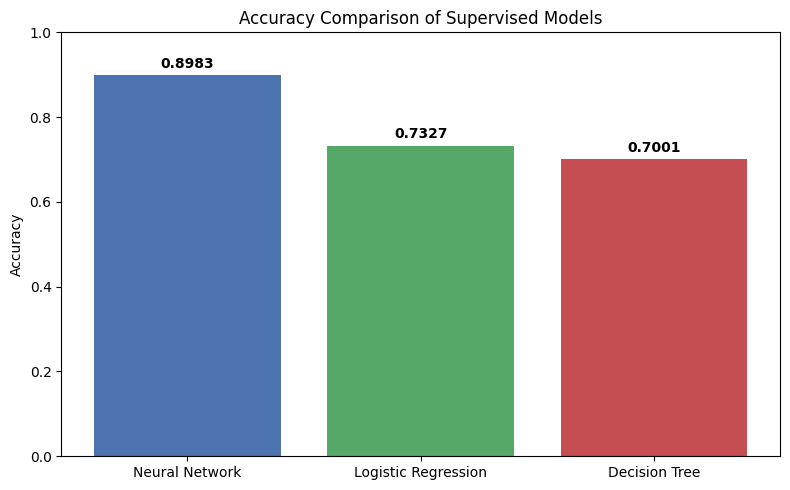

In [ ]:
plt.figure(figsize=(8, 5))
bars = plt.bar(results_df['Model'], results_df['Accuracy'], color=['#4C72B0', '#55A868', '#C44E52'])
plt.title('Accuracy Comparison of Supervised Models')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

### 8.2 Precision & Recall Comparison

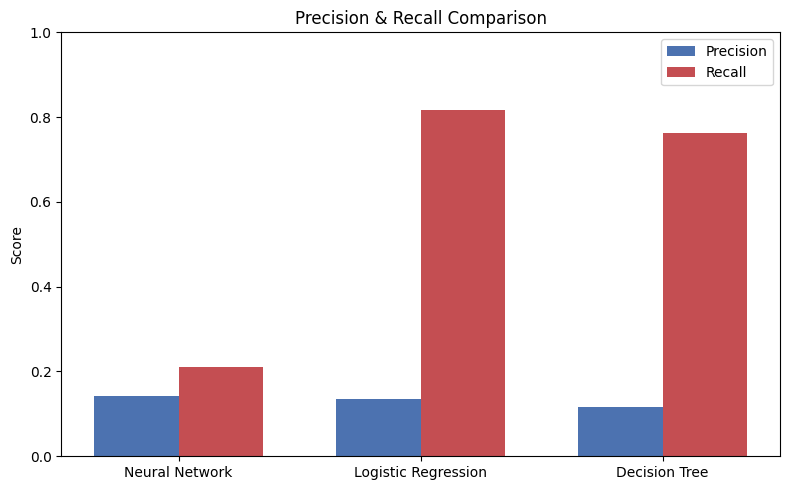

In [ ]:
x = np.arange(len(results_df))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, results_df['Precision'], width, label='Precision', color='#4C72B0')
bars2 = ax.bar(x + width/2, results_df['Recall'], width, label='Recall', color='#C44E52')

ax.set_ylabel('Score')
ax.set_title('Precision & Recall Comparison')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'])
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

### 8.3 Confusion Matrices

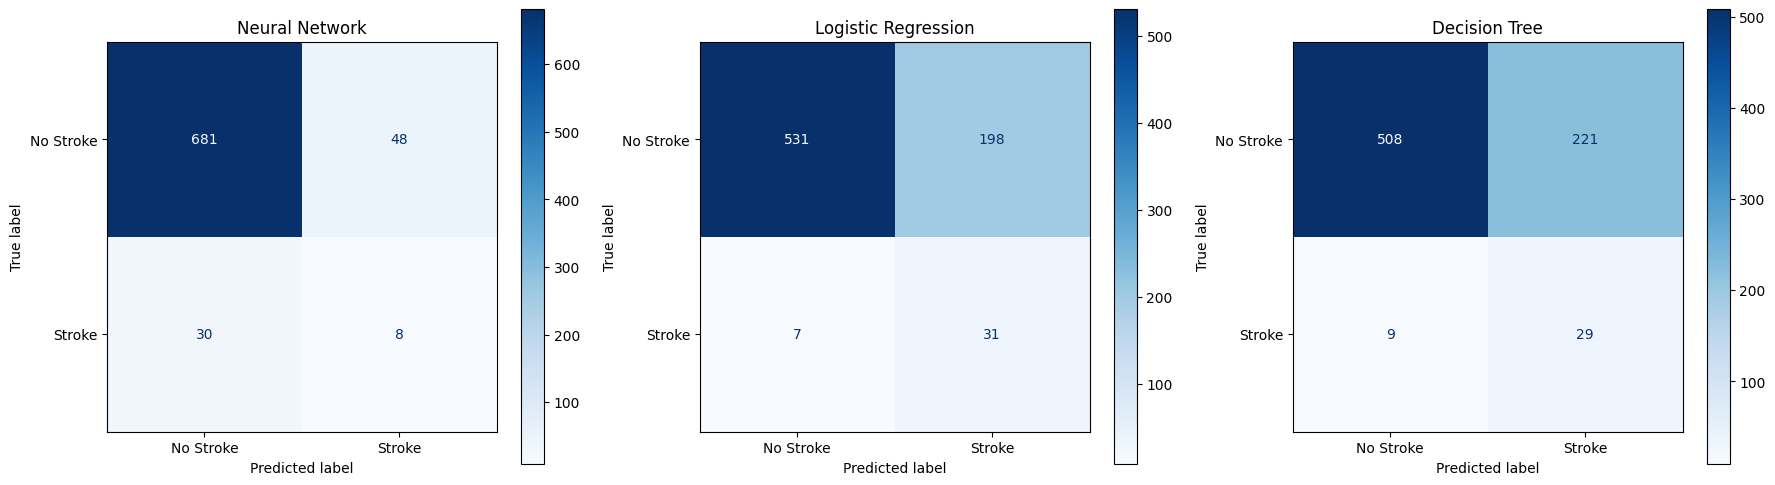

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, (y_pred, _)) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stroke', 'Stroke'])
    disp.plot(ax=axes[i], cmap='Blues')
    axes[i].set_title(f'{name}')
plt.tight_layout()
plt.show()

### 8.4 ROC Curves & AUC Scores

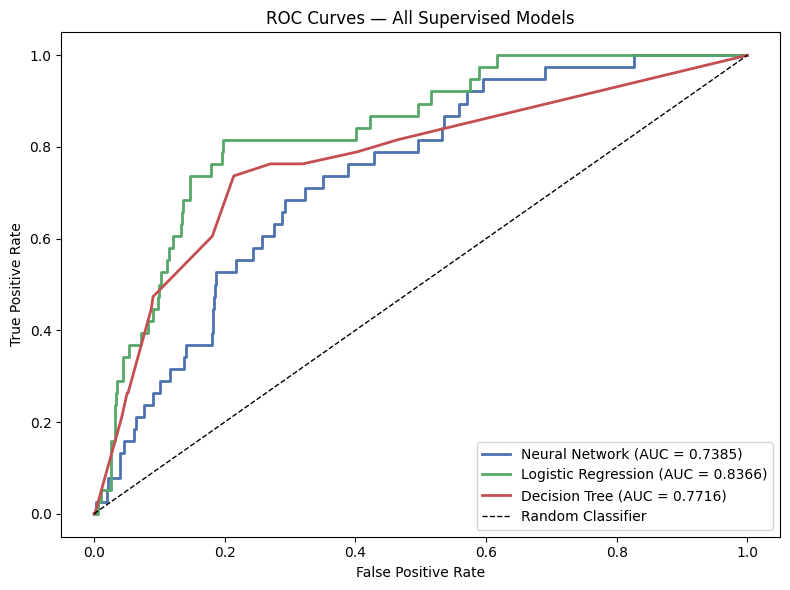

In [ ]:
plt.figure(figsize=(8, 6))
colors = ['#4C72B0', '#55A868', '#C44E52']
for i, (name, (_, y_prob)) in enumerate(models.items()):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', color=colors[i], linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Supervised Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 9. Conclusion

### Key Findings:
- The dataset is **heavily imbalanced** (~95% no stroke, ~5% stroke), which is the biggest challenge.
- After applying random oversampling on the training set, all three models were able to learn patterns in the minority class.
- **Age**, **hypertension**, **heart_disease**, and **avg_glucose_level** are the most correlated features with stroke occurrence.
- The **correlation between individual features and stroke is generally weak**, making accurate prediction difficult.

### Model Performance:
- The results (accuracy, precision, recall, F1, AUC) are shown in the comparison table and charts above.
- Due to the inherent difficulty of the problem (few positive samples, weak feature correlations), achieving very high precision AND recall simultaneously is challenging.
- The **ROC-AUC score** is a more reliable metric than accuracy for this imbalanced dataset.

### Challenges:
1. **Severe class imbalance** — only ~5% of samples are positive (stroke).
2. **Missing `bmi` values** — required imputation.
3. **Weak feature correlations** — no single feature is a strong predictor of stroke.
4. **Small number of positive samples** — makes it hard for models to learn the minority class well.

### Possible Improvements:
- Use more advanced oversampling techniques (e.g., SMOTE).
- Try ensemble methods (Random Forest, Gradient Boosting).
- Perform hyperparameter tuning using cross-validation.
- Collect more data, especially positive stroke cases.